In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
# Defining inputs and expected output (XOR truth table)
X = np.array([[0, 0],[0, 1],[1, 0], [1,1]]).T
d = np.array([0, 1, 1, 0])#Expected output for XOR

In [7]:
def initialize_network_parameters(): 
    #Network parameters 
    inputSize = 2 # number of input neurons 
    hiddenSize = 2 # number of hidden neurons
    outputSize = 1 # number of output neurons
    lr = 0.1 # learning rate 
    epochs = 180000 #number of training epochs
    # Intialize weights and biases randomly in the range of [-1, -1]
    w1 = np.random.rand(hiddenSize, inputSize)* 2 - 1 # Weights from input to hidden layer 
    b1 = np.random.rand(hiddenSize ,1)* 2 - 1 # Bias for hidden layer 
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # weights from hidden to output layer 
    b2 = np.random.rand(outputSize, 1)* 2 - 1 # bias from hidden to output layer
    return w1, b1, w2, b2, lr, epochs

In [8]:
w1, b1, w2, b2, lr, epochs = initialize_network_parameters() 
# training the netowrk using backpropagation 
error_list = [] 
for epoch in range(epochs): 
    #Forward pass 
    z1 = np.dot(w1, X) + b1 #Weighted sum for hidden layer 
    a1 = 1 /(1 + np.exp(-z1)) #Sigmoid activation for hidden layer 
    z2 = np.dot(w2, a1) + b2 # weighted sum for output layer 
    a2 = 1/ (1 + np.exp(-z2)) # Sigmoid activation for output layer 
    #Error calculation and backpropagation 
    error = d - a2 #Difference between expected and actual output 
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

Epoch: 9999, Average error: 0.27836
Epoch: 19999, Average error: 0.26685
Epoch: 29999, Average error: 0.26287
Epoch: 39999, Average error: 0.26074
Epoch: 49999, Average error: 0.25937
Epoch: 59999, Average error: 0.25840
Epoch: 69999, Average error: 0.25767
Epoch: 79999, Average error: 0.25709
Epoch: 89999, Average error: 0.25662
Epoch: 99999, Average error: 0.25623
Epoch: 109999, Average error: 0.25590
Epoch: 119999, Average error: 0.25562
Epoch: 129999, Average error: 0.25537
Epoch: 139999, Average error: 0.25515
Epoch: 149999, Average error: 0.25495
Epoch: 159999, Average error: 0.25478
Epoch: 169999, Average error: 0.25462
Epoch: 179999, Average error: 0.25447


In [9]:
# Testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))



Final output after training: [[0.00968693 0.99206189 0.49986504 0.50013552]]
Ground truth [0 1 1 0]
Error after training: [[-0.00968696  0.00793813  0.50013496 -0.50013553]]
Average error: 0.25447


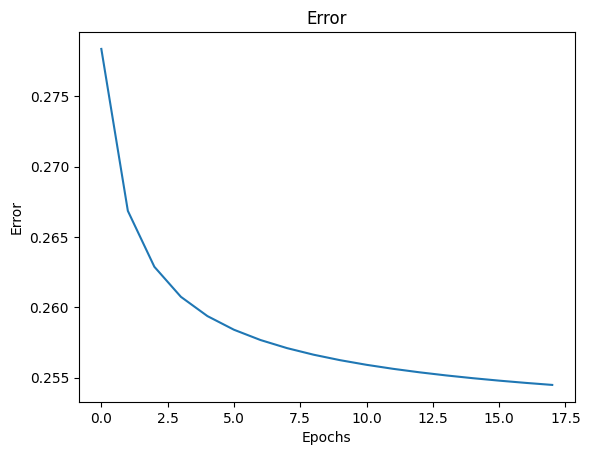

In [10]:
# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()